In [1]:
import numpy as np

In [2]:
ksvd_model = np.load('ksvd_checkpoint.npz', allow_pickle=True)

In [3]:
print("Keys:", ksvd_model.files)

# Print shape, dtype, and a small preview of each variable
for key in ksvd_model.files:
    data = ksvd_model[key]
    print(f"\n--- {key} ---")
    print("Shape:", data.shape)
    print("Dtype:", data.dtype)
    print("Type:", type(data))
    print("Data:", data)

Keys: ['D', 'Gamma', 'unused', 'replaced', 'errors_', 'completed_iter', 'n_iter', 'n_components', 'n_nonzero_coefs', 'n_features', 'n_samples', 'n_frozen']

--- D ---
Shape: (864, 864)
Dtype: float32
Type: <class 'numpy.ndarray'>
Data: [[-0.05636882 -0.03783354  0.03523353 ...  0.00566099  0.02102889
   0.05083337]
 [-0.05219771 -0.03865795  0.06117054 ...  0.03445253 -0.05655125
   0.09362162]
 [-0.03852196 -0.0406983   0.05663475 ...  0.03409544 -0.07317807
   0.00521446]
 ...
 [-0.10265919 -0.02968854 -0.04710248 ...  0.0291796  -0.02926234
  -0.0118185 ]
 [-0.13357714 -0.03078107 -0.05964477 ... -0.02172747 -0.02582476
  -0.01536267]
 [-0.12100925 -0.02801571 -0.04720762 ... -0.02528142 -0.02749529
  -0.03163752]]

--- Gamma ---
Shape: (864, 7533)
Dtype: float32
Type: <class 'numpy.ndarray'>
Data: [[0.        0.        0.        ... 0.        2.3167427 0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.     

In [4]:
patches_2d = np.load('unified_train_2d.npz', allow_pickle=True)

In [5]:
print("Keys:", patches_2d.files)

# Print shape, dtype, and a small preview of each variable
for key in patches_2d.files:
    data = patches_2d[key]
    print(f"\n--- {key} ---")
    print("Shape:", data.shape)
    print("Dtype:", data.dtype)
    print("Type:", type(data))
    print("Data:", data)

Keys: ['X', 'H', 'scan_ids', 'coords']



--- X ---
Shape: (864, 7533)
Dtype: float64
Type: <class 'numpy.ndarray'>
Data: [[-0.21156573 -0.60118562 -0.62695199 ... -0.59712464  0.75172663
   0.74399781]
 [-0.6116637  -0.63512468 -0.63608718 ... -0.11014223  0.73794818
   0.73842895]
 [-0.7235381  -0.65790606 -0.68938071 ...  0.67088854  0.72998714
   0.72460794]
 ...
 [ 0.68216717  0.71928096  0.58185947 ... -0.15107113 -0.51459157
  -0.66096365]
 [ 0.6284641   0.69986391  0.19818377 ... -0.12669015 -0.6450116
  -0.68113405]
 [ 0.64396977  0.68106055 -0.31775552 ... -0.276007   -0.66768384
  -0.59917963]]

--- H ---
Shape: (7533,)
Dtype: int64
Type: <class 'numpy.ndarray'>
Data: [3 3 3 ... 3 3 3]

--- scan_ids ---
Shape: (7533,)
Dtype: object
Type: <class 'numpy.ndarray'>
Data: ['train_11150_b_2' 'train_11150_b_2' 'train_11150_b_2' ...
 'train_13316_a_2' 'train_13316_a_2' 'train_13316_a_2']

--- coords ---
Shape: (7533, 3)
Dtype: int64
Type: <class 'numpy.ndarray'>
Data: [[149 337 136]
 [149 341 136]
 [149 341 140]
 ...
 [381

In [6]:
np.unique(patches_2d["scan_ids"])

array(['train_1089_a_1', 'train_10938_a_1', 'train_11023_b_1',
       'train_11068_a_1', 'train_11150_b_2', 'train_11522_a_1',
       'train_1157_e_2', 'train_11829_b_1', 'train_11903_a_2',
       'train_1199_a_1', 'train_119_a_2', 'train_122_b_1',
       'train_122_c_1', 'train_12309_a_1', 'train_12563_e_1',
       'train_1267_a_1', 'train_13316_a_2', 'train_1387_a_2',
       'train_1513_a_2', 'train_1591_c_2', 'train_1734_a_1',
       'train_1758_a_2', 'train_1758_b_2', 'train_1767_a_2',
       'train_1905_a_2', 'train_1959_b_2', 'train_1987_a_2',
       'train_2149_a_1', 'train_2159_a_5', 'train_2167_a_2',
       'train_2209_a_2', 'train_2394_a_1', 'train_2492_a_1',
       'train_2504_a_2', 'train_2775_a_2', 'train_2825_a_2',
       'train_2913_b_2', 'train_2918_a_2', 'train_2938_a_1',
       'train_321_a_2', 'train_340_a_1', 'train_398_a_1', 'train_412_c_2',
       'train_479_a_2', 'train_5212_a_2', 'train_5377_a_2',
       'train_5551_a_2', 'train_5730_a_1', 'train_5857_a_2',
    

In [7]:
import json
import numpy as np

# Load JSON
with open(r"C:\Users\chamu\D\UOR\FYP\fyp\data\rexgrounding-ct\dataset_filtered.json", "r") as f:
    dataset_filtered = json.load(f)

# Scan IDs available in patches_2d
# These are assumed to NOT contain ".nii.gz"
scan_ids = set(np.unique(patches_2d["scan_ids"]).tolist())

matches = []

for item in dataset_filtered["train"]:
    # Normalize the JSON scan name
    scan_name = item["name"]
    scan_name = scan_name.removesuffix(".nii.gz")  # remove ".nii.gz"

    # Check whether this scan exists in patches_2d
    if scan_name not in scan_ids:
        continue

    findings = item.get("findings", {})
    entity_counts = item.get("entity_counts", {})

    # Must have exactly 1 finding
    if len(findings) != 1:
        continue

    # Get the ID of the single finding
    finding_id = next(iter(findings))

    # That finding must have exactly 1 entity
    if entity_counts.get(finding_id) != 1:
        continue

    matches.append(item)

print("Number of matching scans:", len(matches))

for item in matches:
    finding_id = next(iter(item["findings"]))

    print(
        f"{item['name']} | "
        f"Finding: {item['findings'][finding_id]} | "
        f"Entities: {item['entity_counts'][finding_id]}"
    )

Number of matching scans: 13
train_12563_e_1.nii.gz | Finding: Irregularly circumscribed nodular density increases in the anteromediobasal segment of the lower lobe of the left lung, measuring approximately 21x16 mm | Entities: 1
train_5212_a_2.nii.gz | Finding: 9 mm calcified nodule on the diaphragmatic side of the lower lobe of the left lung | Entities: 1
train_5857_a_2.nii.gz | Finding: 10 mm nodular lesion with lobulated contours at the junction of the right middle lobe medial and upper lobe anterior segment | Entities: 1
train_59_a_2.nii.gz | Finding: 5 mm nodule in the anterior segment of the left upper lobe | Entities: 1
train_649_a_2.nii.gz | Finding: 5 mm spiculated nodule in the right lower lobe | Entities: 1
train_7662_a_1.nii.gz | Finding: Subcentimeter nonspecific parenchymal nodule in the subpleural region of the right middle lobe | Entities: 1
train_7880_a_1.nii.gz | Finding: 12 mm nodule in the posterior segment of the right upper lobe | Entities: 1
train_7993_a_2.nii.g

In [8]:
import matplotlib.pyplot as plt

X = patches_2d['X']
scan_ids = patches_2d['scan_ids']
coords = patches_2d['coords']

# Find all patches belonging to this scan
scan_id = 'train_7880_a_1'
indices = np.where(scan_ids == scan_id)[0]
print("Number of patches:", len(indices))

Number of patches: 10


Middle patch index: 0
Patch shape (flattened): (864,)
Coordinates (x, y, z): [149 337 136]
3D patch shape: (12, 12, 6)
Middle slice shape: (12, 12)


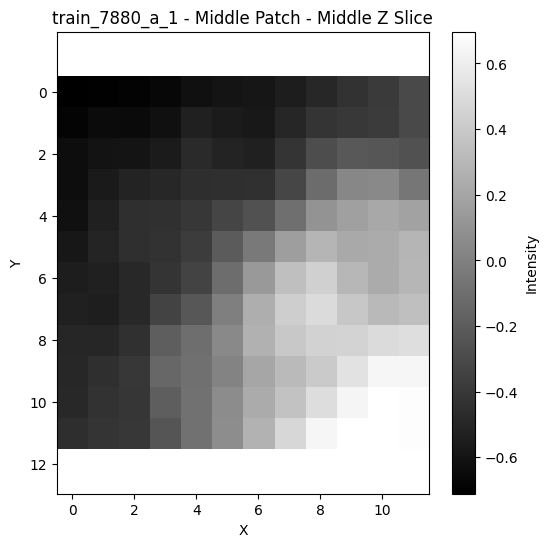

In [9]:
# Take the middle patch
middle_idx = 0
patch = X[:, middle_idx]
print("Middle patch index:", middle_idx)
print("Patch shape (flattened):", patch.shape)
print("Coordinates (x, y, z):", coords[middle_idx])

# Reshape the patch — dims are (X, Y, Z) = (12, 12, 6)
patch_3d = patch.reshape(12, 12, 6)
print("3D patch shape:", patch_3d.shape)

# Take the middle slice along Z (last axis)
middle_slice = patch_3d[:, :, patch_3d.shape[2] // 2]
print("Middle slice shape:", middle_slice.shape)

# Visualize
plt.figure(figsize=(6, 6))
plt.imshow(middle_slice, cmap='gray')
plt.colorbar(label='Intensity')
plt.title(f'{scan_id} - Middle Patch - Middle Z Slice')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()

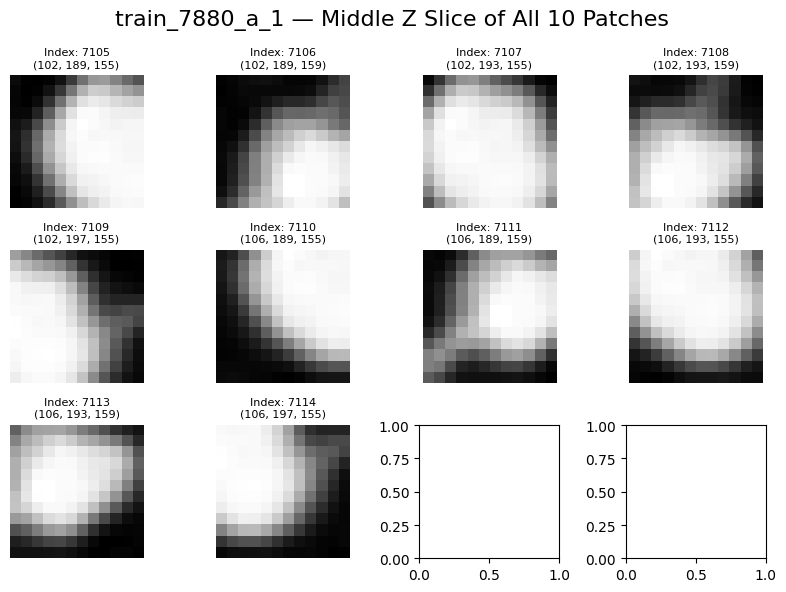

In [10]:
# Create grid
fig, axes = plt.subplots(3, 4, figsize=(8, 6))

for ax, idx in zip(axes.flat, indices):
    patch = X[:, idx] # Get flattened patch
    patch_3d = patch.reshape(12, 12, 6) # Reshape to (X, Y, Z)
    middle_slice = patch_3d[:, :, patch_3d.shape[2] // 2] # Middle slice along Z

    # Display
    ax.imshow(middle_slice, cmap='gray')

    # Show patch coordinate (x, y, z)
    coord = coords[idx]
    ax.set_title(
        f"Index: {idx}\n({coord[0]}, {coord[1]}, {coord[2]})",
        fontsize=8
    )
    ax.axis('off')

fig.suptitle(
    f'{scan_id} — Middle Z Slice of All {len(indices)} Patches',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [11]:
def _crop_or_pad_1d(size: int, target: int) -> tuple[slice, tuple[int, int]]:
    """
    Return (source_slice, pad_width) for a single axis:
      - if size >= target: a centered crop slice of length `target`, no padding.
      - if size <  target: the full source slice, plus symmetric pad widths
        that bring it up to `target`.
    """
    if size >= target:
        start = (size - target) // 2
        return slice(start, start + target), (0, 0)
    total_pad = target - size
    before = total_pad // 2
    after = total_pad - before
    return slice(0, size), (before, after)


def crop_or_pad(vol: np.ndarray, target_shape: tuple[int, int, int], pad_value: float) -> np.ndarray:
    """Center-crop and/or pad a 3D array (H, W, D) to target_shape."""
    if vol.shape == tuple(target_shape):
        return vol

    slices, pad_widths = [], []
    for size, target in zip(vol.shape, target_shape):
        sl, pw = _crop_or_pad_1d(size, target)
        slices.append(sl)
        pad_widths.append(pw)

    cropped = vol[tuple(slices)]
    if any(pw != (0, 0) for pw in pad_widths):
        cropped = np.pad(cropped, pad_widths, mode='constant', constant_values=pad_value)
    return cropped


def crop_or_pad_mask(mask: np.ndarray, target_shape: tuple[int, int, int], pad_value: int = 0) -> np.ndarray:
    """Apply crop_or_pad independently to each finding slice of a 4D mask [F, H, W, D]."""
    frames = [crop_or_pad(mask[f], target_shape, pad_value) for f in range(mask.shape[0])]
    return np.stack(frames, axis=0).astype(np.uint8)


In [12]:
import nibabel as nib
import numpy as np
from scipy import ndimage

path = f'C:\\Users\\chamu\\D\\UOR\\FYP\\fyp\\data\\segmentations\\segmentations\\{scan_id}.nii.gz'

nii = nib.load(path)
mask = nii.get_fdata()

print(mask.shape)
print(mask.dtype)
print(np.unique(mask))

mask = np.squeeze(mask, axis=0)  # drop the finding-index dim (F=1 for this file)
print(mask.shape)

original_spacing = (np.float32(0.6738281), np.float32(0.6738281), np.float32(1.5)) # same as volume
target_spacing = (0.75, 0.75, 1.5)

# 1. Resample to TARGET_SPACING_MM — mirrors resample_volume's zoom factors
zoom_factors = np.asarray(original_spacing, dtype=np.float32) / np.asarray(target_spacing, dtype=np.float32)

mask_resampled = ndimage.zoom(
    mask,
    zoom_factors,
    order=0,          # nearest-neighbour: preserve integer labels
    mode='nearest'
)
print("Resampled shape:", mask_resampled.shape)
print("Unique values:", np.unique(mask_resampled))

# 2. Center-crop / pad directly to TARGET_SHAPE
TARGET_SHAPE = (480, 480, 240)
mask_final = crop_or_pad_mask(mask_resampled[np.newaxis, ...], TARGET_SHAPE, pad_value=0)[0]

print("\nFinal shape:", mask_final.shape)
print("Unique values:", np.unique(mask_final))

(1, 512, 512, 242)
float64
[0. 1.]
(512, 512, 242)
Resampled shape: (460, 460, 242)
Unique values: [0. 1.]

Final shape: (480, 480, 240)
Unique values: [0 1]


1295


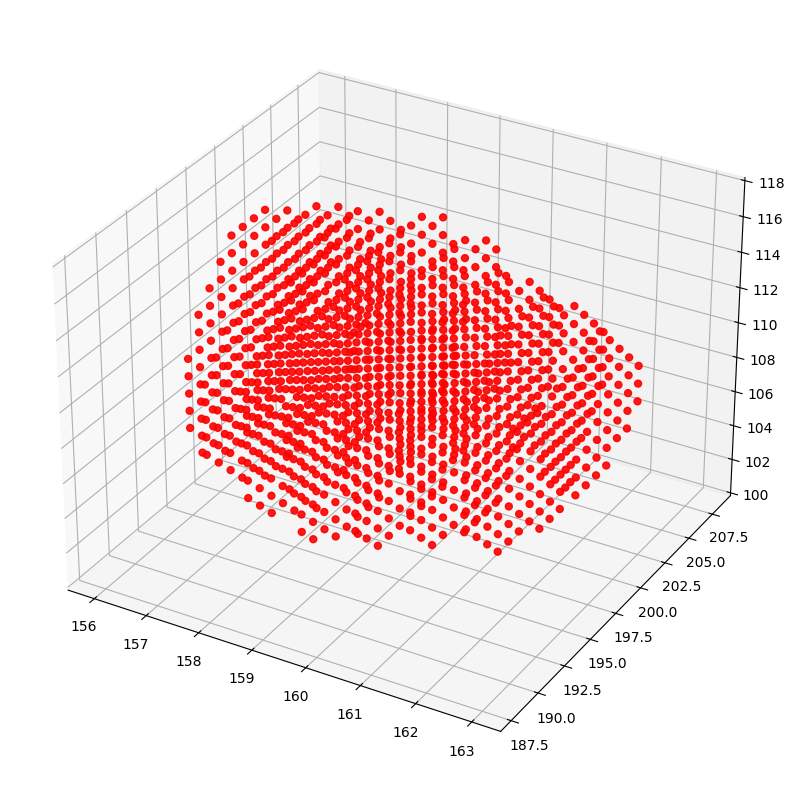

In [13]:
# number of ground truth voxels in the resized mask
print(np.sum(mask_final > 0))

# visualize positive voxels in the resized mask in a 3D scatter plot
z, y, x = np.where(mask_final > 0)

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='red', s=25, alpha=0.9)
plt.show()

Coordinate range:
min: [102 189 155]
max: [106 197 159]
Patch space shape: (np.int64(16), np.int64(20), np.int64(10))
Mask crop shape: (16, 20, 10) expected: (np.int64(16), np.int64(20), np.int64(10))
Mask voxels in crop: 1290
Total voxels: 3200


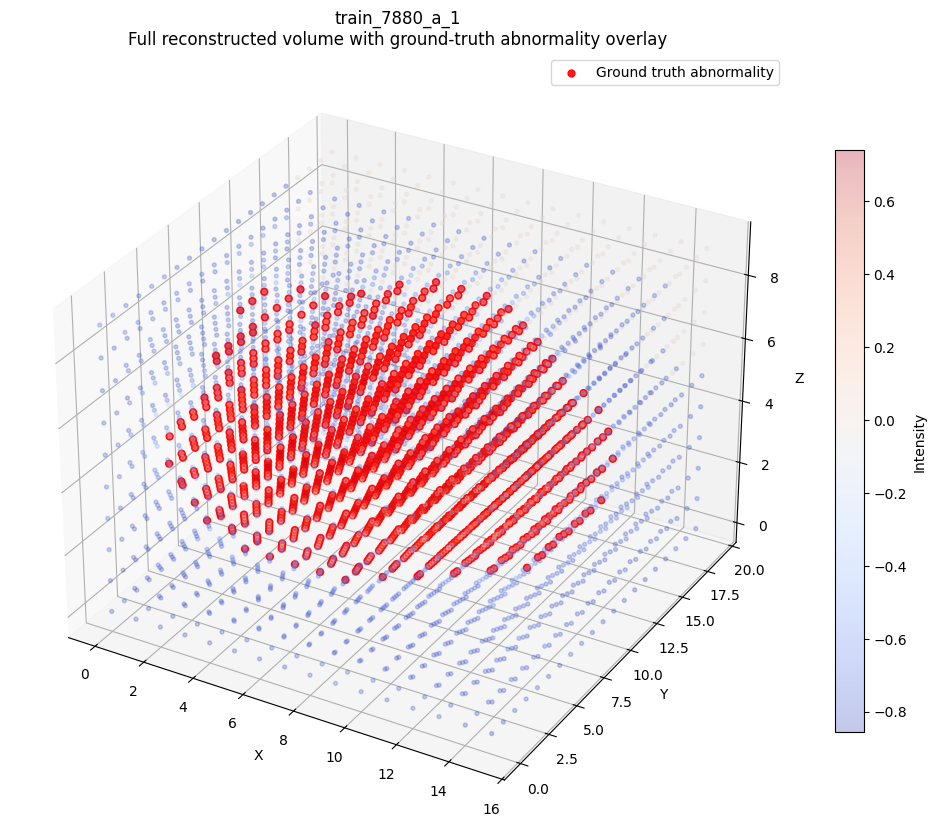

In [14]:
patch_shape = (12, 12, 6)
assert np.prod(patch_shape) == X.shape[0]

# Find extent of the complete patch grid
scan_coords = coords[indices]

print("Coordinate range:")
print("min:", scan_coords.min(axis=0))
print("max:", scan_coords.max(axis=0))

# coords = (x, y, z); patch_shape = (12, 12, 6) = (X, Y, Z)
patch_size_x, patch_size_y, patch_size_z = patch_shape

min_coord = scan_coords.min(axis=0)
max_coord = scan_coords.max(axis=0)

# Overall patch space dimensions
patch_space_shape = (
    max_coord[0] - min_coord[0] + patch_size_x,
    max_coord[1] - min_coord[1] + patch_size_y,
    max_coord[2] - min_coord[2] + patch_size_z
)
print("Patch space shape:", patch_space_shape)

# Create volume
volume = np.zeros(patch_space_shape, dtype=np.float32)
count = np.zeros(patch_space_shape, dtype=np.int32)

# Put patches into the common 3D volume
for idx in indices:
    patch = X[:, idx].reshape(patch_shape)
    coord = coords[idx]
    x, y, z = coord

    x0 = x - min_coord[0]
    y0 = y - min_coord[1]
    z0 = z - min_coord[2]

    x1 = x0 + patch_size_x
    y1 = y0 + patch_size_y
    z1 = z0 + patch_size_z

    volume[x0:x1, y0:y1, z0:z1] += patch
    count[x0:x1, y0:y1, z0:z1] += 1

mask = count > 0
volume[mask] /= count[mask]

# --------------------------------------------------
# Crop the ground-truth mask to the same region as `volume`
# --------------------------------------------------
# mask_resized is assumed to already be in the same global (X, Y, Z)
# coordinate space as `coords`.
gt_x0, gt_y0, gt_z0 = min_coord
gt_x1 = gt_x0 + patch_space_shape[0]
gt_y1 = gt_y0 + patch_space_shape[1]
gt_z1 = gt_z0 + patch_space_shape[2]

mask_crop = mask_final[gt_x0:gt_x1, gt_y0:gt_y1, gt_z0:gt_z1]
print("Mask crop shape:", mask_crop.shape, "expected:", patch_space_shape)
print("Mask voxels in crop:", np.count_nonzero(mask_crop))

# Local coordinates (relative to min_coord) of ground-truth abnormality voxels
mask_x, mask_y, mask_z = np.where(mask_crop > 0)

# --------------------------------------------------
# Show the full reconstructed volume, with mask overlaid
# --------------------------------------------------
xi, yi, zi = np.indices(volume.shape)
xi = xi.ravel()
yi = yi.ravel()
zi = zi.ravel()
values = volume.ravel()

print("Total voxels:", len(values))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Background: intensity volume
scatter = ax.scatter(
    xi, yi, zi,
    c=values,
    cmap='coolwarm',
    s=8,
    alpha=0.3,
)

# Overlay: ground-truth abnormality mask
ax.scatter(
    mask_x, mask_y, mask_z,
    c='red',
    s=25,
    alpha=0.9,
    label='Ground truth abnormality',
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_title(
    f'{scan_id}\n'
    f'Full reconstructed volume with ground-truth abnormality overlay'
)

fig.colorbar(scatter, ax=ax, label='Intensity', shrink=0.6)
ax.legend()

plt.tight_layout()
plt.show()

Ground-truth voxels in patch grid: 1290
Nodule centroid (global x, y, z): [109.30542636 198.00542636 159.29224806]
Selected patch position (of 10 ): 2
Global patch index: 7107
Patch coordinate (x, y, z): [102 193 155]
Distance to nodule centroid: 2.088832151808287
Ground-truth voxels inside selected patch: 627


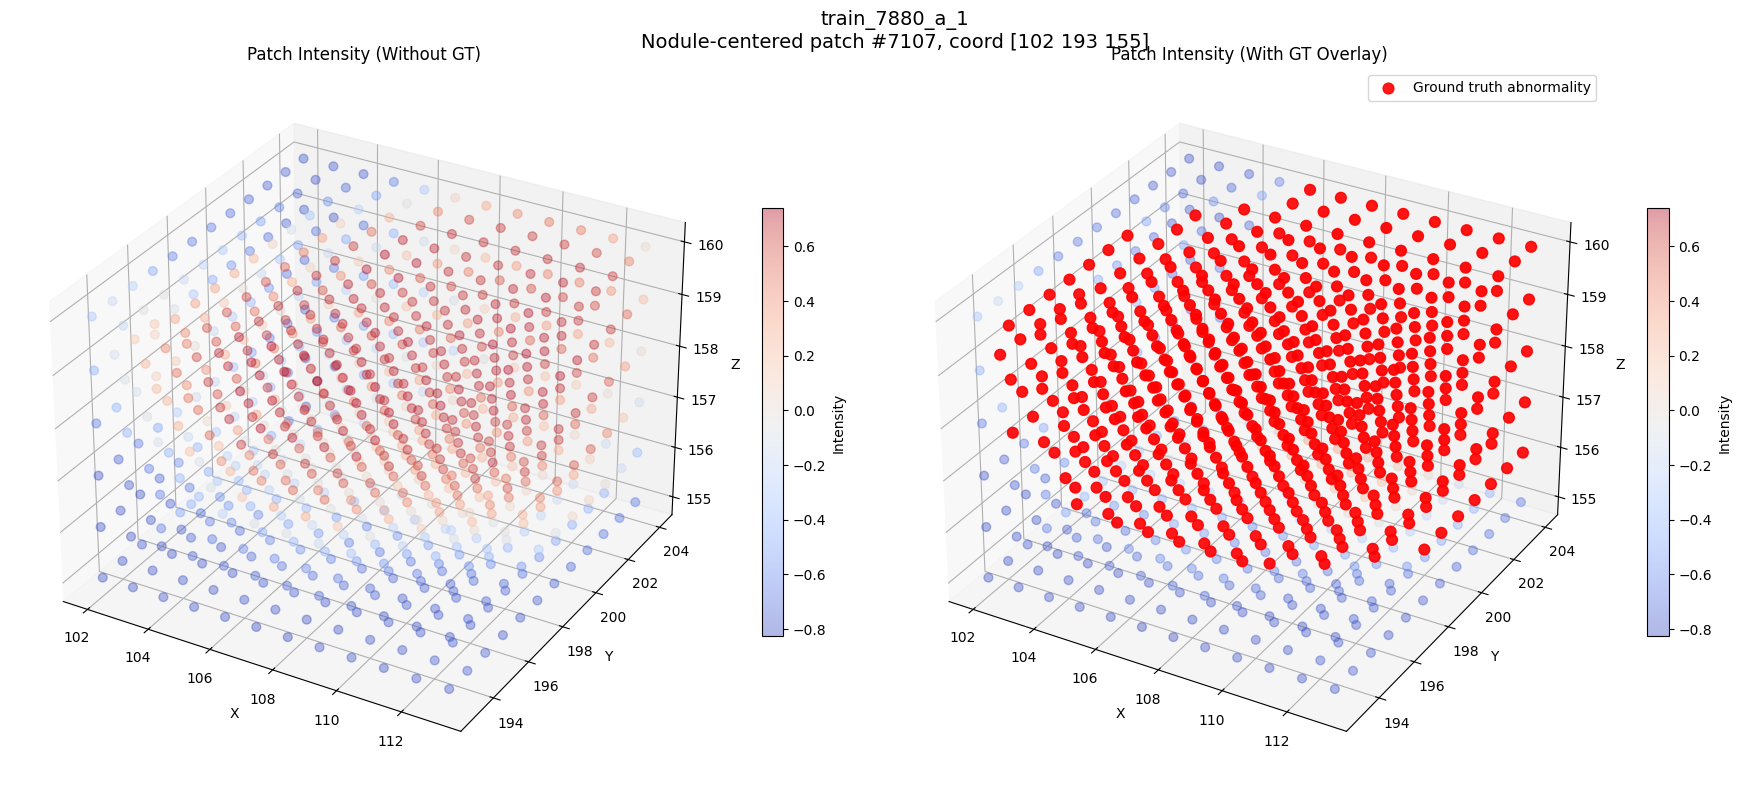

In [15]:
# Nodule center from ground-truth mask voxels (cell 13's mask_x/y/z)
assert len(mask_x) > 0, "No ground-truth voxels found within the patch grid"

nodule_centroid_local = np.array([
    mask_x.mean(),
    mask_y.mean(),
    mask_z.mean(),
])
nodule_centroid_global = nodule_centroid_local + min_coord

print("Ground-truth voxels in patch grid:", len(mask_x))
print("Nodule centroid (global x, y, z):", nodule_centroid_global)

# Pick the patch whose center is closest to the nodule centroid
patch_half_extent = np.array(patch_shape) / 2.0  # (x, y, z)
patch_centers = coords[indices] + patch_half_extent
distances = np.linalg.norm(patch_centers - nodule_centroid_global, axis=1)

centered_position = np.argmin(distances)
centered_idx = indices[centered_position]

print("Selected patch position (of", len(indices), "):", centered_position)
print("Global patch index:", centered_idx)
print("Patch coordinate (x, y, z):", coords[centered_idx])
print("Distance to nodule centroid:", distances[centered_position])

# Visualize just this patch, with ground-truth voxels overlaid
x0, y0, z0 = coords[centered_idx]
centered_patch = X[:, centered_idx].reshape(patch_shape)  # (X, Y, Z)

# Patch voxel intensities, local -> global coordinates
xi, yi, zi = np.indices(patch_shape)
xi = xi.ravel() + x0
yi = yi.ravel() + y0
zi = zi.ravel() + z0
patch_values = centered_patch.ravel()

# Ground-truth voxels within this patch's global bounding box
patch_mask = mask_final[x0:x0 + patch_shape[0],
                         y0:y0 + patch_shape[1],
                         z0:z0 + patch_shape[2]]
gt_x, gt_y, gt_z = np.where(patch_mask > 0)
gt_x = gt_x + x0
gt_y = gt_y + y0
gt_z = gt_z + z0
print("Ground-truth voxels inside selected patch:", len(gt_x))

# Create a figure with 2 side-by-side 3D subplots
fig = plt.figure(figsize=(18, 8))

# --- Plot 1: Without Ground-Truth Overlay ---
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    xi, yi, zi,
    c=patch_values,
    cmap='coolwarm',
    s=40,
    alpha=0.4,
)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.set_title("Patch Intensity (Without GT)")
fig.colorbar(scatter1, ax=ax1, label='Intensity', shrink=0.6)

# --- Plot 2: With Ground-Truth Overlay ---
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    xi, yi, zi,
    c=patch_values,
    cmap='coolwarm',
    s=40,
    alpha=0.4,
)
ax2.scatter(
    gt_x, gt_y, gt_z,
    c='red',
    s=60,
    alpha=0.9,
    label='Ground truth abnormality',
)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_title("Patch Intensity (With GT Overlay)")
ax2.legend()
fig.colorbar(scatter2, ax=ax2, label='Intensity', shrink=0.6)

fig.suptitle(
    f"{scan_id}\nNodule-centered patch #{centered_idx}, coord {coords[centered_idx]}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [16]:
from reppi import OMP
from lc_ksvd.metrics import normalise_columns

N_NONZERO_COEFS = 10

X = patches_2d['X'].astype(np.float32)
D = ksvd_model['D'].astype(np.float32)

def encode_patches_omp(X: np.ndarray, D: np.ndarray, n_nonzero_coefs: int) -> np.ndarray:
    X_norm, _, _ = normalise_columns(X)
    omp = OMP(n_nonzero_coefs=n_nonzero_coefs, mode="batch", check_dict=True)
    Gamma = omp.encode(X_norm, D)
    return Gamma

Gamma = encode_patches_omp(X, D, N_NONZERO_COEFS)

Processing samples with Batch-OMP: 100%|██████████| 7533/7533 [00:09<00:00, 813.92it/s]


Number of patches: 10
Selected patch position (of 10 ): 2
Global patch index: 7107
Patch coordinate (x, y, z): [102 193 155]
Distance to nodule centroid: 2.088832151808287
Sparse code shape: (864,)
Number of non-zero coefficients: 10


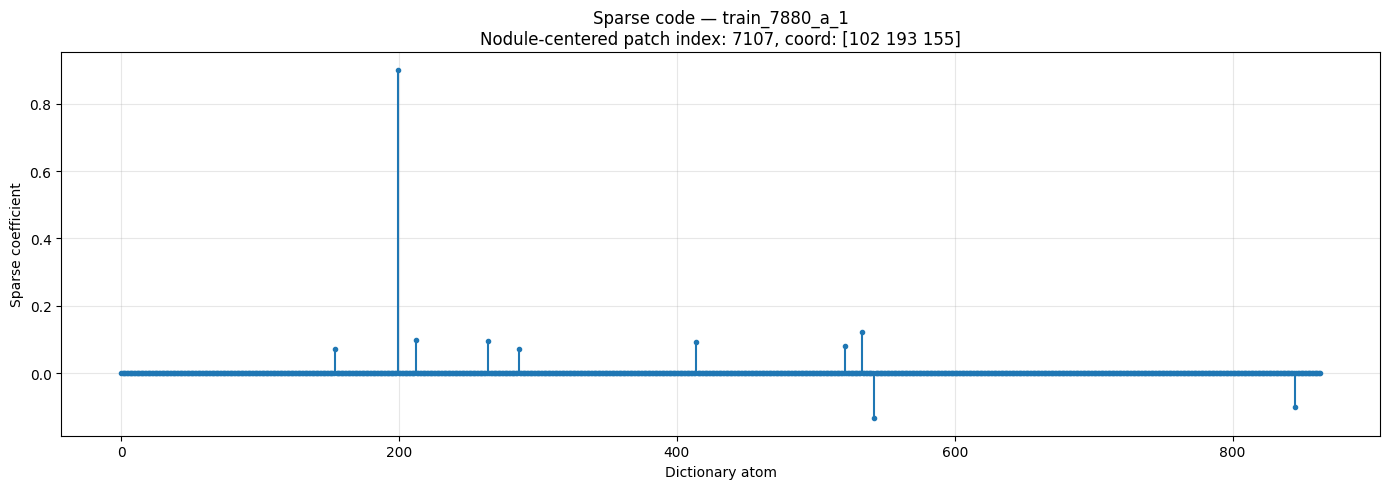

In [17]:
indices = np.where(scan_ids == scan_id)[0]

print("Number of patches:", len(indices))

# Pick the patch whose center is closest to the ground-truth nodule centroid
patch_half_extent = np.array(patch_shape) / 2.0  # (x, y, z)
patch_centers = coords[indices] + patch_half_extent
distances = np.linalg.norm(patch_centers - nodule_centroid_global, axis=1)

centered_position = np.argmin(distances)
centered_idx = indices[centered_position]

print("Selected patch position (of", len(indices), "):", centered_position)
print("Global patch index:", centered_idx)
print("Patch coordinate (x, y, z):", coords[centered_idx])
print("Distance to nodule centroid:", distances[centered_position])

# Get sparse code for this patch
gamma_centered = Gamma[:, centered_idx]

print("Sparse code shape:", gamma_centered.shape)
print("Number of non-zero coefficients:",
      np.count_nonzero(gamma_centered))

# Plot all 864 coefficients
plt.figure(figsize=(14, 5))

plt.stem(
    np.arange(len(gamma_centered)),
    gamma_centered,
    markerfmt='.',
    basefmt=' '
)

plt.xlabel("Dictionary atom")
plt.ylabel("Sparse coefficient")
plt.title(
    f"Sparse code — {scan_id}\n"
    f"Nodule-centered patch index: {centered_idx}, "
    f"coord: {coords[centered_idx]}"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Find non-zero coefficients for the nodule-centered patch
nonzero = np.flatnonzero(gamma_centered)
coef_values = gamma_centered[nonzero]

print("Active dictionary atoms:")
for atom, value in zip(nonzero, coef_values):
    print(f"Atom {atom:3d}: {value:.6f}")

Active dictionary atoms:
Atom 154: 0.071432
Atom 199: 0.900151
Atom 212: 0.098142
Atom 264: 0.097249
Atom 286: 0.071259
Atom 414: 0.092347
Atom 521: 0.082492
Atom 533: 0.122993
Atom 542: -0.133155
Atom 845: -0.099327


Top 3 atoms:
1. Atom 199: coefficient = 0.900151
2. Atom 542: coefficient = -0.133155
3. Atom 533: coefficient = 0.122993

Patch origin (x, y, z): 102 193 155
Ground-truth voxels inside this patch: 627

Similarity of top-3 reconstruction to ground-truth region:
  MAE:              0.4404
  RMSE:             0.4928
  Correlation:      0.8875
  Intensity ratio:  5.13%  (combined sum / original sum, within GT region)


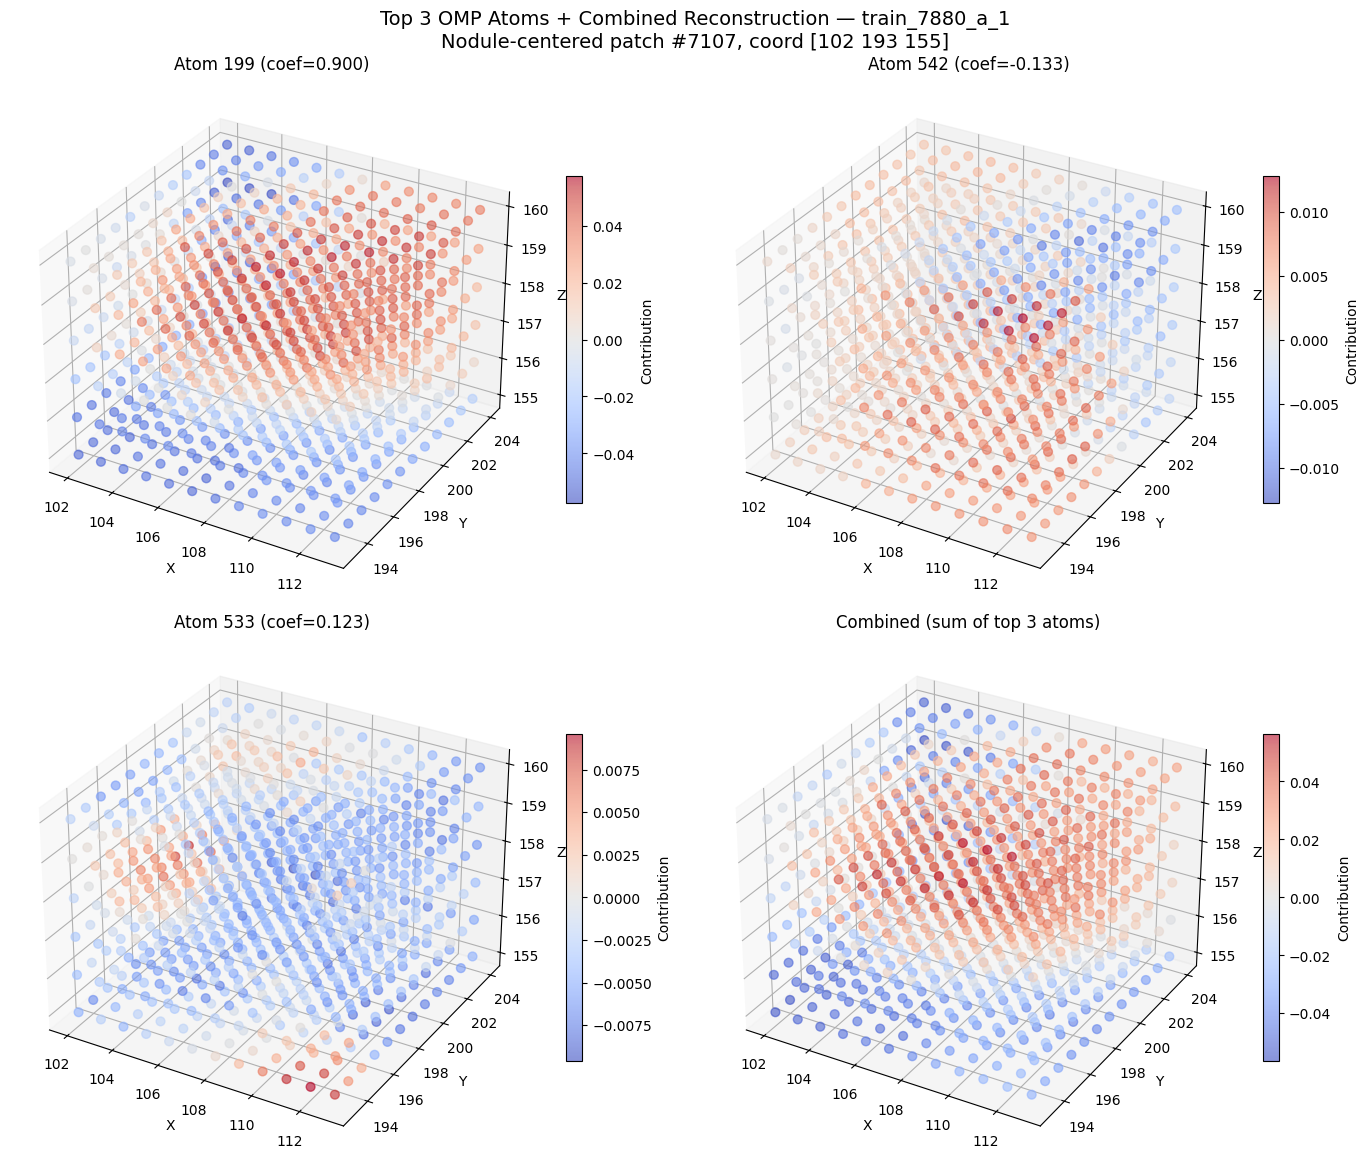

In [19]:
# Active atoms for the nodule-centered patch
active_atoms = np.flatnonzero(gamma_centered)

# Sort by absolute coefficient magnitude
sorted_atoms = active_atoms[
    np.argsort(np.abs(gamma_centered[active_atoms]))[::-1]
]

top_atoms = sorted_atoms[:3]  # Top 3
print("Top 3 atoms:")

for rank, atom in enumerate(top_atoms, 1):
    print(
        f"{rank}. Atom {atom}: "
        f"coefficient = {gamma_centered[atom]:.6f}"
    )

# --------------------------------------------------
# Reconstruct each atom's individual contribution by multiplying the
# dictionary with a sparse code that has ONLY that atom's coefficient
# (all other coefficients zeroed out) — D @ gamma_single
# --------------------------------------------------
D = ksvd_model['D']
patch_shape = (12, 12, 6)  # (X, Y, Z)

atom_patches = {}
for atom in top_atoms:
    gamma_single = np.zeros_like(gamma_centered)
    gamma_single[atom] = gamma_centered[atom]
    atom_patches[atom] = (D @ gamma_single).reshape(patch_shape)

# Sum of the 3 individual single-atom reconstructions
combined_patch = sum(atom_patches[atom] for atom in top_atoms)

# Global origin of the selected (nodule-centered) patch
x0, y0, z0 = coords[centered_idx]
print("\nPatch origin (x, y, z):", x0, y0, z0)

# --------------------------------------------------
# Original patch intensities + ground-truth mask within this patch
# --------------------------------------------------
centered_patch = X[:, centered_idx].reshape(patch_shape)

patch_mask = mask_final[
    x0:x0 + patch_shape[0],
    y0:y0 + patch_shape[1],
    z0:z0 + patch_shape[2]
]
gt_voxel_count = np.count_nonzero(patch_mask)
print("Ground-truth voxels inside this patch:", gt_voxel_count)

# --------------------------------------------------
# How well does the top-3 reconstruction match the original patch
# intensity, specifically within the ground-truth region?
# (The mask itself is binary — it has no intensity, so we compare
# against the real patch intensity at those mask voxels.)
# --------------------------------------------------
if gt_voxel_count > 0:
    gt_region = patch_mask > 0
    orig_in_gt = centered_patch[gt_region]
    combined_in_gt = combined_patch[gt_region]

    mae = np.mean(np.abs(combined_in_gt - orig_in_gt))
    rmse = np.sqrt(np.mean((combined_in_gt - orig_in_gt) ** 2))
    corr = (
        np.corrcoef(combined_in_gt, orig_in_gt)[0, 1]
        if gt_voxel_count > 1 else float('nan')
    )
    orig_sum = orig_in_gt.sum()
    intensity_ratio = combined_in_gt.sum() / orig_sum if orig_sum != 0 else float('nan')

    print("\nSimilarity of top-3 reconstruction to ground-truth region:")
    print(f"  MAE:              {mae:.4f}")
    print(f"  RMSE:             {rmse:.4f}")
    print(f"  Correlation:      {corr:.4f}")
    print(f"  Intensity ratio:  {intensity_ratio:.2%}  (combined sum / original sum, within GT region)")
else:
    print("No ground-truth voxels inside this patch — cannot compute similarity.")

# --------------------------------------------------
# Visualize each atom's contribution and the combined sum.
# No threshold: every voxel in the patch is shown, so the combined
# plot's intensities are directly comparable to the original patch.
# --------------------------------------------------
xi, yi, zi = np.indices(patch_shape)
xi = xi.ravel()
yi = yi.ravel()
zi = zi.ravel()

fig = plt.figure(figsize=(14, 12))

plot_items = [
    (f"Atom {atom}", atom_patches[atom], f"coef={gamma_centered[atom]:.3f}")
    for atom in top_atoms
]
plot_items.append(
    ("Combined", combined_patch, f"sum of top {len(top_atoms)} atoms")
)

for rank, (label, patch, subtitle) in enumerate(plot_items, 1):
    ax = fig.add_subplot(2, 2, rank, projection='3d')
    voxel_values = patch.ravel()
    peak = np.abs(patch).max()

    scatter = ax.scatter(
        xi + x0, yi + y0, zi + z0,
        c=voxel_values,
        cmap='coolwarm',
        vmin=-peak,
        vmax=peak,
        s=40,
        alpha=0.6,
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"{label} ({subtitle})")
    fig.colorbar(scatter, ax=ax, shrink=0.6, label='Contribution')

fig.suptitle(
    f"Top 3 OMP Atoms + Combined Reconstruction — {scan_id}\n"
    f"Nodule-centered patch #{centered_idx}, coord {coords[centered_idx]}",
    fontsize=14
)
plt.tight_layout()
plt.show()

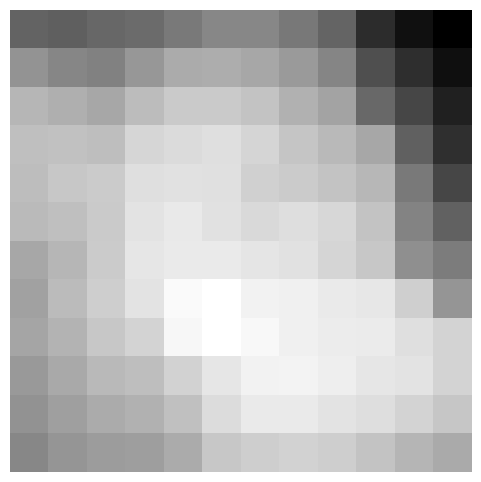

In [21]:
import numpy as np
import matplotlib.pyplot as plt

D = ksvd_model['D'].astype(np.float32)

atom_idx = 199

# Get atom 199
atom = D[:, atom_idx]

# Reshape to (X, Y, Z)
atom_3d = atom.reshape(12, 12, 6)

# Middle slice along Z
middle_z = atom_3d[:, :, atom_3d.shape[2] // 2]

# Visualize
plt.figure(figsize=(6, 6))
plt.imshow(middle_z, cmap='gray')
plt.axis('off')
plt.show()